# Wczytanie danych

In [1]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/Dane/dane/domy_bristol.csv", delimiter=";")
data.head()

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,lad23cd,transactionid,lmk_key,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,CONSTRUCTION_AGE_BAND
0,4195.416667,2018,7.09.2018,T,F,503450,BS3 4QH,E06000023,{773788C2-38FE-2CE4-E053-6C04A8C05E57},1607498582832018021211071471978909,120.0,6.0,11,59,80,England and Wales: before 1900
1,2000.000000,2006,15.12.2006,T,F,240000,BS3 4QH,E06000023,{57BF87C7-A6DB-40A1-9A01-3C7E4C6D4520},1607498582832018021211071471978909,120.0,6.0,11,59,80,England and Wales: before 1900
2,2387.387387,2018,11.05.2018,T,F,265000,BS7 9UE,E06000023,{6DA08449-92E6-30F2-E053-6B04A8C05F3B},1603864816852018012917162890280258,111.0,5.0,11,56,76,England and Wales: 1967-1975
3,378.378378,1996,19.09.1996,T,F,42000,BS7 9UE,E06000023,{322E0AF7-99B8-44D1-8996-890C566A2945},1603864816852018012917162890280258,111.0,5.0,11,56,76,England and Wales: 1967-1975
4,702.702703,2001,30.11.2001,T,F,78000,BS7 9UE,E06000023,{0ECC4A80-8E6D-4473-BF1B-B7F0ECC50C81},1603864816852018012917162890280258,111.0,5.0,11,56,76,England and Wales: 1967-1975


In [2]:
data = data.drop(columns=['lad23cd','transactionid','lmk_key','CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY','CONSTRUCTION_AGE_BAND','classt'])

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177870 entries, 0 to 177869
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   priceper        177750 non-null  float64
 1   year            177870 non-null  int64  
 2   dateoftransfer  177870 non-null  object 
 3   propertytype    177870 non-null  object 
 4   duration        177870 non-null  object 
 5   price           177870 non-null  int64  
 6   postcode        177870 non-null  object 
 7   tfarea          177870 non-null  float64
 8   numberrooms     165977 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 12.2+ MB


In [4]:
data.head()

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,tfarea,numberrooms
0,4195.416667,2018,7.09.2018,T,F,503450,BS3 4QH,120.0,6.0
1,2000.000000,2006,15.12.2006,T,F,240000,BS3 4QH,120.0,6.0
2,2387.387387,2018,11.05.2018,T,F,265000,BS7 9UE,111.0,5.0
3,378.378378,1996,19.09.1996,T,F,42000,BS7 9UE,111.0,5.0
4,702.702703,2001,30.11.2001,T,F,78000,BS7 9UE,111.0,5.0


# Brakujące wartości

In [5]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [6]:
missing_data[:4]

,missing value,percentage
numberrooms,11893,6.686344
priceper,120,0.067465
year,0,0.000000
propertytype,0,0.000000


In [7]:
data['numberrooms'] = data['numberrooms'].fillna(data['numberrooms'].median())

In [8]:
data = data[data['priceper'].notna()]

# Wartości odstające

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
priceper,177750.0,2455.536212,1606.037405,0.974659,1368.421053,2264.957265,3314.273109,8.146067e+04
year,177750.0,2009.811347,8.273152,1995.000000,2003.000000,2010.000000,2017.000000,2.024000e+03
price,177750.0,213853.416630,167314.866058,195.000000,112000.000000,174950.000000,270000.000000,3.500000e+06
tfarea,177750.0,89.903459,41.930046,1.430000,67.000000,84.480000,103.000000,3.039000e+03
numberrooms,177750.0,4.390650,1.598034,1.000000,3.000000,4.000000,5.000000,8.500000e+01


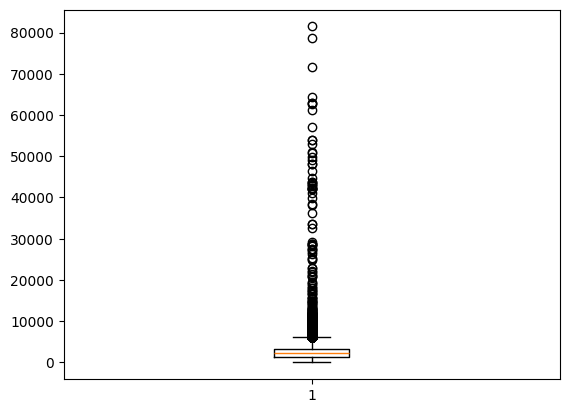

In [10]:
import matplotlib.pyplot as plt
plt.boxplot(x=data['priceper'])
plt.show()

In [11]:
import numpy as np
q1 = np.quantile(data['numberrooms'], 0.25)
q3 = np.quantile(data['numberrooms'], 0.75)
iqr = q3-q1
upper_lim = q3+(5*iqr)
lower_lim = q1-(5*iqr)

In [12]:
outliers_1 = data[(data['numberrooms'] > upper_lim) | (data['numberrooms'] < lower_lim)]
outliers_1

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,tfarea,numberrooms
689,1177.024482,2002,24.01.2002,S,F,250000,BS9 4RL,212.40,16.0
4867,1975.000000,2005,7.01.2005,T,F,158000,BS3 3EZ,80.00,85.0
4868,2625.000000,2013,14.06.2013,T,F,210000,BS3 3EZ,80.00,85.0
4869,2725.000000,2007,14.09.2007,T,F,218000,BS3 3EZ,80.00,85.0
4870,861.875000,1999,17.11.1999,T,F,68950,BS3 3EZ,80.00,85.0
9422,2653.679654,2013,30.08.2013,S,F,613000,BS9 3DW,231.00,17.0
9423,1969.696970,2004,22.07.2004,D,F,455000,BS9 3DW,231.00,17.0
28507,2790.697674,2013,3.05.2013,S,F,240000,BS9 4QP,86.00,51.0
35278,1882.352941,2010,29.01.2010,S,F,560000,BS9 4EY,297.50,19.0
48113,4491.379310,2016,15.06.2016,F,L,260500,BS8 2DE,58.00,25.0


51 pokoi?

In [13]:
data = data[~((data['numberrooms'] > upper_lim) | (data['numberrooms'] < lower_lim))]

# Kody pocztowe -> dzielnice

In [14]:
pc = pd.read_csv("/content/drive/MyDrive/Dane/dane/Bristol postcodes.csv")
pc.head()

,Postcode,In Use?,Latitude,Longitude,Easting,Northing,Grid Ref,Introduced,Terminated,Altitude,Population,Households,Nearest Station,Distance To Station (KM),Built Up Area,District,Ward,County Electoral Division
0,BS1 1AA,No,51.449515,-2.578372,359905,172440,ST599724,2/1/1990 12:00:00 AM,12/1/1998 12:00:00 AM,15,NaN,NaN,Bristol Temple Meads,0.2,Bristol,"Bristol, City of",Lawrence Hill,NaN
1,BS1 1AB,No,51.449515,-2.578372,359905,172440,ST599724,2/1/1990 12:00:00 AM,12/1/1999 12:00:00 AM,15,NaN,NaN,Bristol Temple Meads,0.2,Bristol,"Bristol, City of",Lawrence Hill,NaN
2,BS1 1AD,Yes,51.458455,-2.574166,360205,173432,ST602734,8/1/1992 12:00:00 AM,NaN,17,NaN,NaN,Lawrence Hill,0.7,Bristol,"Bristol, City of",Lawrence Hill,NaN
3,BS1 1AE,No,51.449515,-2.578372,359905,172440,ST599724,7/1/1995 12:00:00 AM,6/1/2000 12:00:00 AM,15,NaN,NaN,Bristol Temple Meads,0.2,Bristol,"Bristol, City of",Lawrence Hill,NaN
4,BS1 1AF,No,51.449515,-2.578372,359905,172440,ST599724,7/1/1995 12:00:00 AM,9/1/2000 12:00:00 AM,15,NaN,NaN,Bristol Temple Meads,0.2,Bristol,"Bristol, City of",Lawrence Hill,NaN


In [15]:
data['neighbourhood'] = data['postcode'].map(pc.set_index('Postcode')['Ward'])

In [16]:
data.head()

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,tfarea,numberrooms,neighbourhood
0,4195.416667,2018,7.09.2018,T,F,503450,BS3 4QH,120.0,6.0,Windmill Hill
1,2000.000000,2006,15.12.2006,T,F,240000,BS3 4QH,120.0,6.0,Windmill Hill
2,2387.387387,2018,11.05.2018,T,F,265000,BS7 9UE,111.0,5.0,Lockleaze
3,378.378378,1996,19.09.1996,T,F,42000,BS7 9UE,111.0,5.0,Lockleaze
4,702.702703,2001,30.11.2001,T,F,78000,BS7 9UE,111.0,5.0,Lockleaze


# Konwersja typów

In [17]:
data['propertytype'] = data['propertytype'].str.replace('D', 'Wolnostojący', regex=False)
data['propertytype'] = data['propertytype'].str.replace('S', 'Bliźniak', regex=False)
data['propertytype'] = data['propertytype'].str.replace('T', 'Szeregowy', regex=False)
data['propertytype'] = data['propertytype'].str.replace('F', 'Mieszkanie', regex=False)

In [18]:
data['propertytype'].head()

,propertytype
0,Szeregowy
1,Szeregowy
2,Szeregowy
3,Szeregowy
4,Szeregowy


In [19]:
data['duration'] = data['duration'].str.replace('F', 'Własność', regex=False)
data['duration'] = data['duration'].str.replace('L', 'Dzierżawa', regex=False)

In [20]:
data['neighbourhood'] = data['neighbourhood'].str.replace(' and ', ' & ', regex=False)

In [21]:
numeryczne = data.select_dtypes(include='number')
numeryczne.head()

,priceper,year,price,tfarea,numberrooms
0,4195.416667,2018,503450,120.0,6.0
1,2000.000000,2006,240000,120.0,6.0
2,2387.387387,2018,265000,111.0,5.0
3,378.378378,1996,42000,111.0,5.0
4,702.702703,2001,78000,111.0,5.0


In [22]:
for col in numeryczne:
  data[col] = data[col].astype(str)
  data[col] = data[col].str.replace('.', ',', regex=False)

In [23]:
data = data[data['year'] >= '2016']

In [24]:
data.to_csv('bristol_houses_cleaned.csv', index=False)